In [1]:
from ultralytics import YOLO
from tensorflow.keras.models import load_model

# ==============================
# LOAD YOLO
# ==============================

yolo_path = r"D:\Smartvision_project\final_models\smartvision_yolov8n_25class_best.pt"

yolo_model = YOLO(yolo_path)

print("✅ YOLO loaded successfully")
print("YOLO classes:", len(yolo_model.names))


# ==============================
# LOAD CNN
# ==============================

cnn_path = r"D:\Smartvision_project\efficientnetb0_final.keras"

cnn_model = load_model(cnn_path)

print("✅ EfficientNetB0 loaded successfully")
print("CNN input shape:", cnn_model.input_shape)
print("CNN output shape:", cnn_model.output_shape)

✅ YOLO loaded successfully
YOLO classes: 25
✅ EfficientNetB0 loaded successfully
CNN input shape: (None, 224, 224, 3)
CNN output shape: (None, 25)


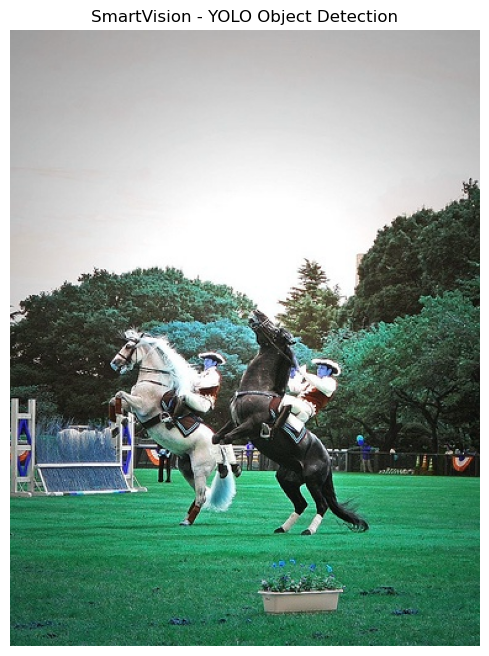

========== YOLO DETECTIONS ==========
No objects detected.


In [2]:
from PIL import Image
import matplotlib.pyplot as plt

# Pick one validation image
image_path = r"D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000002.jpg"

# Run YOLO
results = yolo_model.predict(
    source=image_path,
    conf=0.25,
    verbose=False
)

# Get the result
result = results[0]

# Display detection result
annotated_image = result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("SmartVision - YOLO Object Detection")
plt.show()

# Print detected objects
print("========== YOLO DETECTIONS ==========")

if len(result.boxes) == 0:
    print("No objects detected.")
else:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = yolo_model.names[class_id]

        print(
            f"{class_name:15s} | "
            f"Confidence: {confidence:.2f}"
        )

In [3]:
# Run YOLO with a very low confidence threshold
results_low = yolo_model.predict(
    source=image_path,
    conf=0.01,
    verbose=False
)

result_low = results_low[0]

print("========== RAW YOLO CHECK ==========")
print("Number of detections:", len(result_low.boxes))

if len(result_low.boxes) > 0:
    for box in result_low.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = yolo_model.names[class_id]

        print(
            f"{class_name:15s} | "
            f"Confidence: {confidence:.4f}"
        )
else:
    print("❌ No detections even at confidence 0.01")

========== RAW YOLO CHECK ==========
Number of detections: 61
horse           | Confidence: 0.1122
person          | Confidence: 0.1043
person          | Confidence: 0.0992
person          | Confidence: 0.0797
person          | Confidence: 0.0690
person          | Confidence: 0.0642
dog             | Confidence: 0.0508
person          | Confidence: 0.0408
person          | Confidence: 0.0408
person          | Confidence: 0.0363
dog             | Confidence: 0.0332
person          | Confidence: 0.0325
person          | Confidence: 0.0309
horse           | Confidence: 0.0286
person          | Confidence: 0.0285
person          | Confidence: 0.0233
person          | Confidence: 0.0232
person          | Confidence: 0.0231
horse           | Confidence: 0.0230
person          | Confidence: 0.0224
person          | Confidence: 0.0216
person          | Confidence: 0.0211
person          | Confidence: 0.0199
person          | Confidence: 0.0196
person          | Confidence: 0.0193
person       

In [4]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Folder containing the YOLO results that looked good
results_folder = r"D:\Smartvision_project\yolo_predictions\validation_results"

# Find a few result images
result_images = [
    f for f in os.listdir(results_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total result images:", len(result_images))

# Test the first 10 images and find one with detections
for filename in result_images[:10]:

    path = os.path.join(results_folder, filename)

    results_test = yolo_model.predict(
        source=path,
        conf=0.25,
        verbose=False
    )

    number = len(results_test[0].boxes)

    print(f"{filename}: {number} detections")

Total result images: 425
image_000002.jpg: 0 detections
image_000005.jpg: 0 detections
image_000007.jpg: 0 detections
image_000010.jpg: 1 detections
image_000027.jpg: 2 detections
image_000046.jpg: 0 detections
image_000047.jpg: 0 detections
image_000050.jpg: 0 detections
image_000055.jpg: 0 detections
image_000065.jpg: 4 detections


In [5]:
# Use an image where YOLO detected objects
test_image = r"D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000027.jpg"

results = yolo_model.predict(
    source=test_image,
    conf=0.25,
    verbose=False
)

result = results[0]

print("========== YOLO RESULT ==========")
print("Detections:", len(result.boxes))

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = yolo_model.names[class_id]

    print(
        f"Class: {class_name:15s} | "
        f"Confidence: {confidence:.2f}"
    )

========== YOLO RESULT ==========
Detections: 2
Class: person          | Confidence: 0.64
Class: dog             | Confidence: 0.34


In [6]:
def detect_objects(image_path, confidence_threshold=0.25):
    """
    Run YOLO object detection on an image.

    Returns:
        result: YOLO detection result
        detections: list of detected objects
    """

    results = yolo_model.predict(
        source=image_path,
        conf=confidence_threshold,
        verbose=False
    )

    result = results[0]

    detections = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        detections.append({
            "class_id": class_id,
            "class_name": yolo_model.names[class_id],
            "confidence": confidence,
            "box": box.xyxy[0].tolist()
        })

    return result, detections


print("✅ YOLO detection function created!")

✅ YOLO detection function created!


In [7]:
result, detections = detect_objects(
    test_image,
    confidence_threshold=0.25
)

print("========== DETECTIONS ==========")

if len(detections) == 0:
    print("No objects detected.")
else:
    for detection in detections:
        print(
            f"{detection['class_name']:15s} | "
            f"Confidence: {detection['confidence']:.2f} | "
            f"Box: {detection['box']}"
        )

========== DETECTIONS ==========
person          | Confidence: 0.64 | Box: [205.5634765625, 6.6512451171875, 640.0, 480.0]
dog             | Confidence: 0.34 | Box: [0.746917724609375, 1.4122161865234375, 164.9866943359375, 182.17672729492188]


In [8]:
# ==========================================
# 4.4 — CHECK NMS + BOUNDING BOXES
# ==========================================

result, detections = detect_objects(
    test_image,
    confidence_threshold=0.25
)

print("========== NMS / FINAL DETECTIONS ==========")
print("Number of detections after YOLO NMS:", len(detections))

for i, detection in enumerate(detections, start=1):
    print(
        f"{i}. {detection['class_name']:15s} | "
        f"Confidence: {detection['confidence']:.2f}"
    )

print("\n✅ YOLO NMS is being applied automatically.")

========== NMS / FINAL DETECTIONS ==========
Number of detections after YOLO NMS: 2
1. person          | Confidence: 0.64
2. dog             | Confidence: 0.34

✅ YOLO NMS is being applied automatically.


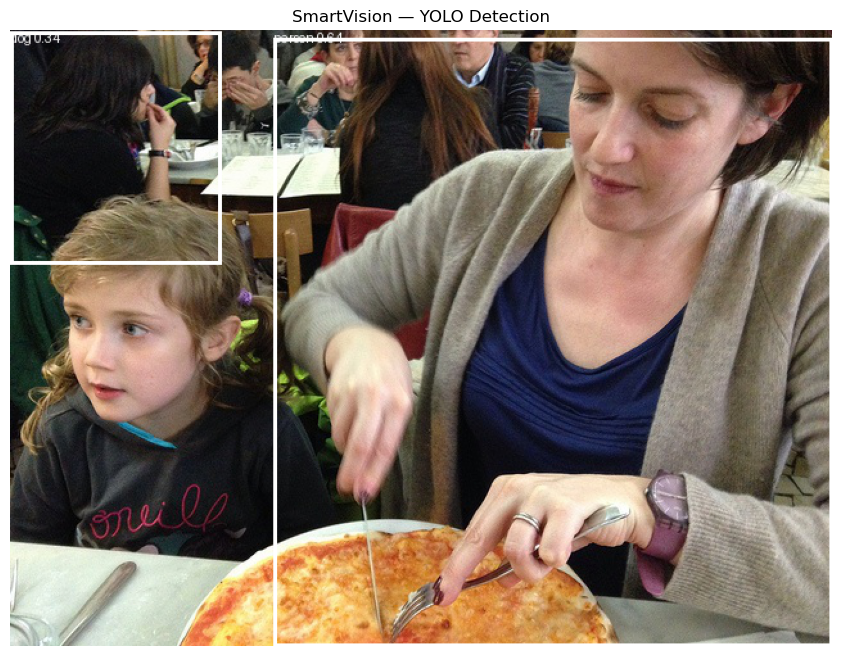

In [9]:
from PIL import Image, ImageDraw

# Open original image
image = Image.open(test_image).convert("RGB")

# Create drawing object
draw = ImageDraw.Draw(image)

# Draw detections
for detection in detections:

    x1, y1, x2, y2 = detection["box"]

    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    label = (
        f"{detection['class_name']} "
        f"{detection['confidence']:.2f}"
    )

    # Bounding box
    draw.rectangle(
        [x1, y1, x2, y2],
        width=3
    )

    # Label
    draw.text(
        (x1, max(0, y1 - 20)),
        label
    )

# Display
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title("SmartVision — YOLO Detection")
plt.show()

In [10]:
print("CNN output classes:", cnn_model.output_shape[-1])

print("\nCNN model loaded successfully.")
print("We need the original classification class order before connecting it.")

CNN output classes: 25

CNN model loaded successfully.
We need the original classification class order before connecting it.


In [11]:
import os

# Your cleaned classification training folder
classification_train = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned\train"

# Get the class folders
cnn_classes = sorted([
    folder for folder in os.listdir(classification_train)
    if os.path.isdir(os.path.join(classification_train, folder))
])

print("========== CNN CLASS MAPPING ==========")
print("Number of classes:", len(cnn_classes))

for i, class_name in enumerate(cnn_classes):
    print(f"{i:2d} -> {class_name}")

========== CNN CLASS MAPPING ==========
Number of classes: 25
 0 -> airplane
 1 -> bed
 2 -> bench
 3 -> bicycle
 4 -> bird
 5 -> bottle
 6 -> bowl
 7 -> bus
 8 -> cake
 9 -> car
10 -> cat
11 -> chair
12 -> couch
13 -> cow
14 -> cup
15 -> dog
16 -> elephant
17 -> horse
18 -> motorcycle
19 -> person
20 -> pizza
21 -> potted plant
22 -> stop sign
23 -> traffic light
24 -> truck


In [12]:
print("========== CNN PREPROCESSING CHECK ==========")

print("Input shape:", cnn_model.input_shape)
print("Output shape:", cnn_model.output_shape)

print("\nFirst 5 layers:")
for i, layer in enumerate(cnn_model.layers[:5]):
    print(i, "->", layer.name, "|", layer.__class__.__name__)

========== CNN PREPROCESSING CHECK ==========
Input shape: (None, 224, 224, 3)
Output shape: (None, 25)

First 5 layers:
0 -> efficientnetb0 | Functional
1 -> global_average_pooling2d_4 | GlobalAveragePooling2D
2 -> batch_normalization_3 | BatchNormalization
3 -> dense_8 | Dense
4 -> dropout_4 | Dropout


In [13]:
# ==========================================
# 4.5.2 — CHECK EFFICIENTNET PREPROCESSING
# ==========================================

efficientnet = cnn_model.layers[0]

print("========== EFFICIENTNET CHECK ==========")
print("Input shape:", efficientnet.input_shape)
print("Output shape:", efficientnet.output_shape)

print("\nFirst 10 EfficientNet layers:")

for i, layer in enumerate(efficientnet.layers[:10]):
    print(
        f"{i:2d} -> {layer.name:30s} | "
        f"{layer.__class__.__name__}"
    )

========== EFFICIENTNET CHECK ==========
Input shape: (None, 224, 224, 3)
Output shape: (None, 7, 7, 1280)

First 10 EfficientNet layers:
 0 -> input_layer_8                  | InputLayer
 1 -> rescaling                      | Rescaling
 2 -> normalization                  | Normalization
 3 -> rescaling_1                    | Rescaling
 4 -> stem_conv_pad                  | ZeroPadding2D
 5 -> stem_conv                      | Conv2D
 6 -> stem_bn                        | BatchNormalization
 7 -> stem_activation                | Activation
 8 -> block1a_dwconv                 | DepthwiseConv2D
 9 -> block1a_bn                     | BatchNormalization


In [14]:
import numpy as np
from PIL import Image

# CNN class mapping
cnn_class_names = cnn_classes


def verify_with_cnn(image_path, detections):
    """
    Take YOLO detections, crop each object,
    and verify it using EfficientNetB0.
    """

    # Open original image
    image = Image.open(image_path).convert("RGB")

    verified_results = []

    for detection in detections:

        # YOLO bounding box
        x1, y1, x2, y2 = detection["box"]

        # Convert to integers
        x1, y1, x2, y2 = map(
            int, [x1, y1, x2, y2]
        )

        # Keep coordinates inside image
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(image.width, x2)
        y2 = min(image.height, y2)

        # Skip invalid boxes
        if x2 <= x1 or y2 <= y1:
            continue

        # Crop object
        cropped = image.crop((x1, y1, x2, y2))

        # Resize for EfficientNet
        cropped = cropped.resize((224, 224))

        # Convert to numpy
        img_array = np.array(cropped, dtype=np.float32)

        # Add batch dimension
        img_array = np.expand_dims(img_array, axis=0)

        # CNN prediction
        predictions = cnn_model.predict(
            img_array,
            verbose=0
        )

        # Best CNN class
        cnn_index = int(np.argmax(predictions[0]))
        cnn_confidence = float(predictions[0][cnn_index])
        cnn_name = cnn_class_names[cnn_index]

        # Save result
        verified_results.append({
            "yolo_class": detection["class_name"],
            "yolo_confidence": detection["confidence"],
            "cnn_class": cnn_name,
            "cnn_confidence": cnn_confidence,
            "box": detection["box"]
        })

    return verified_results


print("✅ YOLO + CNN verification function created!")

✅ YOLO + CNN verification function created!


In [15]:
# ==========================================
# TEST YOLO + CNN
# ==========================================

result, detections = detect_objects(
    test_image,
    confidence_threshold=0.25
)

verified = verify_with_cnn(
    test_image,
    detections
)

print("========== YOLO + CNN RESULTS ==========")

if len(verified) == 0:
    print("No objects available for CNN verification.")

else:
    for i, item in enumerate(verified, start=1):

        print(f"\nObject {i}")

        print(
            f"YOLO : {item['yolo_class']} "
            f"({item['yolo_confidence']:.2f})"
        )

        print(
            f"CNN  : {item['cnn_class']} "
            f"({item['cnn_confidence']:.2f})"
        )

========== YOLO + CNN RESULTS ==========

Object 1
YOLO : person (0.64)
CNN  : person (0.98)

Object 2
YOLO : dog (0.34)
CNN  : cup (0.19)


In [16]:
# ==========================================
# 4.6 — FINAL DECISION LOGIC
# ==========================================

def create_final_results(verified_results, yolo_threshold=0.50):

    final_results = []

    for item in verified_results:

        yolo_class = item["yolo_class"]
        yolo_conf = item["yolo_confidence"]

        cnn_class = item["cnn_class"]
        cnn_conf = item["cnn_confidence"]

        # Only keep sufficiently confident YOLO detections
        if yolo_conf < yolo_threshold:
            continue

        # Compare YOLO and CNN
        if yolo_class == cnn_class:
            status = "Verified"
            final_class = yolo_class
        else:
            status = "YOLO prediction"
            final_class = yolo_class

        final_results.append({
            "class": final_class,
            "confidence": yolo_conf,
            "cnn_class": cnn_class,
            "cnn_confidence": cnn_conf,
            "status": status,
            "box": item["box"]
        })

    return final_results


print("✅ Final decision function created!")

✅ Final decision function created!


In [17]:
# ==========================================
# TEST FINAL DECISION
# ==========================================

final_results = create_final_results(
    verified,
    yolo_threshold=0.50
)

print("========== FINAL SMARTVISION RESULTS ==========")

if len(final_results) == 0:
    print("No confident objects detected.")

else:
    for i, item in enumerate(final_results, start=1):

        print(f"\nObject {i}")
        print(f"Final class : {item['class']}")
        print(f"YOLO confidence : {item['confidence']:.2f}")
        print(f"CNN prediction : {item['cnn_class']} ({item['cnn_confidence']:.2f})")
        print(f"Status : {item['status']}")

========== FINAL SMARTVISION RESULTS ==========

Object 1
Final class : person
YOLO confidence : 0.64
CNN prediction : person (0.98)
Status : Verified


In [18]:
# ==========================================
# 4.7 — COMPLETE SMARTVISION PIPELINE
# ==========================================

def smartvision_pipeline(
    image_path,
    confidence_threshold=0.25,
    final_threshold=0.50
):
    
    # -------------------------------
    # STEP 1: YOLO DETECTION
    # -------------------------------
    
    result, detections = detect_objects(
        image_path,
        confidence_threshold
    )
    
    # -------------------------------
    # STEP 2: CNN VERIFICATION
    # -------------------------------
    
    verified = verify_with_cnn(
        image_path,
        detections
    )
    
    # -------------------------------
    # STEP 3: FINAL DECISION
    # -------------------------------
    
    final_results = create_final_results(
        verified,
        yolo_threshold=final_threshold
    )
    
    return final_results


print("✅ Complete SmartVision pipeline created!")

✅ Complete SmartVision pipeline created!


In [19]:
# ==========================================
# TEST COMPLETE PIPELINE
# ==========================================

results = smartvision_pipeline(
    test_image,
    confidence_threshold=0.25,
    final_threshold=0.50
)

print("========================================")
print("     SMARTVISION FINAL RESULT")
print("========================================")

if len(results) == 0:
    print("No confident objects detected.")

else:
    for i, item in enumerate(results, start=1):
        
        print(f"\nObject {i}")
        print("----------------------------")
        print("Class       :", item["class"])
        print("Confidence  :", f"{item['confidence']:.2f}")
        print("CNN Check   :", item["cnn_class"])
        print("CNN Confidence:", f"{item['cnn_confidence']:.2f}")
        print("Status      :", item["status"])

     SMARTVISION FINAL RESULT

Object 1
----------------------------
Class       : person
Confidence  : 0.64
CNN Check   : person
CNN Confidence: 0.98
Status      : Verified


In [20]:
import time

# ==========================================
# 4.8 — INFERENCE SPEED TEST
# ==========================================

print("========== SMARTVISION SPEED TEST ==========")

# YOLO time
start = time.time()

result, detections = detect_objects(
    test_image,
    confidence_threshold=0.25
)

yolo_time = time.time() - start


# CNN verification time
start = time.time()

verified = verify_with_cnn(
    test_image,
    detections
)

cnn_time = time.time() - start


# Complete pipeline time
start = time.time()

final_results = smartvision_pipeline(
    test_image,
    confidence_threshold=0.25,
    final_threshold=0.50
)

total_time = time.time() - start


print(f"YOLO inference time       : {yolo_time:.3f} seconds")
print(f"CNN verification time    : {cnn_time:.3f} seconds")
print(f"Complete pipeline time    : {total_time:.3f} seconds")

print("\n✅ Speed test completed!")

========== SMARTVISION SPEED TEST ==========
YOLO inference time       : 0.151 seconds
CNN verification time    : 0.326 seconds
Complete pipeline time    : 0.448 seconds

✅ Speed test completed!


In [21]:
import os

project_folder = r"D:\Smartvision_project"

print("========== YOLO MODEL FILES ==========")

for root, dirs, files in os.walk(project_folder):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root, file))

========== YOLO MODEL FILES ==========
D:\Smartvision_project\yolov8n.pt
D:\Smartvision_project\final_models\smartvision_yolov8n_25class_best.pt
D:\Smartvision_project\runs\detect\smartvision_yolo\yolov8n_25class\weights\best.pt
D:\Smartvision_project\runs\detect\smartvision_yolo\yolov8n_25class\weights\last.pt


In [22]:
import os
import shutil

# ==========================================
# CREATE FINAL MODEL FOLDER
# ==========================================

project_folder = r"D:\Smartvision_project"
models_folder = os.path.join(project_folder, "models")

# Create models folder
os.makedirs(models_folder, exist_ok=True)

# Source models
yolo_source = os.path.join(
    project_folder,
    "final_models",
    "smartvision_yolov8n_25class_best.pt"
)

cnn_source = os.path.join(
    project_folder,
    "efficientnetb0_final.keras"
)

# Destination paths
yolo_destination = os.path.join(
    models_folder,
    "smartvision_yolov8n_25class_best.pt"
)

cnn_destination = os.path.join(
    models_folder,
    "efficientnetb0_final.keras"
)

# Copy models
shutil.copy2(yolo_source, yolo_destination)
shutil.copy2(cnn_source, cnn_destination)

print("========== FINAL MODELS ==========")
print("✅ YOLO copied:")
print(yolo_destination)

print("\n✅ CNN copied:")
print(cnn_destination)

print("\n========== MODEL FOLDER ==========")
print(os.listdir(models_folder))

========== FINAL MODELS ==========
✅ YOLO copied:
D:\Smartvision_project\models\smartvision_yolov8n_25class_best.pt

✅ CNN copied:
D:\Smartvision_project\models\efficientnetb0_final.keras

========== MODEL FOLDER ==========
['efficientnetb0_final.keras', 'smartvision_yolov8n_25class_best.pt']
